# EDA — Pulso TransMi

Análisis exploratorio del dataset del reto MLOps **Pulso TransMi**: demanda cada 15 minutos
para 12 estaciones reales de TransMilenio, más contexto de clima y eventos.

El objetivo no es solo describir los datos, sino responder preguntas que condicionan el diseño
del pipeline:

1. ¿Los datos están completos y son confiables?
2. ¿Qué tan distintas son las estaciones entre sí?
3. ¿Qué estacionalidades existen (hora, día de semana)?
4. ¿Hay deriva en el periodo más reciente?
5. ¿Qué lag es el mejor predictor ingenuo?
6. ¿El clima y los eventos aportan señal utilizable al momento de predecir?

Requiere haber ejecutado antes `examples/01_download.py` para poblar `data/`.

In [1]:
from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA = ROOT / "data"
WEEKDAYS = ["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"]
DAY_LAG = 96
WEEK_LAG = 672
CENTER_LAT, CENTER_LON = 4.6097, -74.0817

## Carga de datos

`station_id` se lee como texto: son códigos con ceros a la izquierda (`03000`) que como número
perderían su forma. `observed_at` trae zona horaria `-05:00`, así que se parsea como fecha.

Se derivan `hour`, `weekday` y `date` una sola vez porque casi todas las secciones las reutilizan.

In [2]:
stations = pd.read_csv(DATA / "stations.csv", dtype={"station_id": "string"})

observations = pd.read_csv(
    DATA / "observations.csv",
    dtype={"station_id": "string"},
    parse_dates=["observed_at"],
).sort_values(["station_id", "observed_at"])

context = pd.read_csv(DATA / "context.csv", parse_dates=["observed_at"]).sort_values("observed_at")

observations["hour"] = observations["observed_at"].dt.hour
observations["weekday"] = observations["observed_at"].dt.weekday
observations["date"] = observations["observed_at"].dt.date

stations

,station_id,station_name,corridor,latitude,longitude
0,03000,Portal Suba,Suba,4.746815,-74.094279
1,05000,Portal Américas,Américas,4.629381,-74.173058
2,09000,Portal Usme,Caracas,4.531715,-74.119391
3,02300,Calle 100 - Marketmedios,Autonorte,4.683947,-74.057696
4,09122,Calle 72,Caracas,4.658239,-74.062069
5,05100,Banderas,Américas,4.631301,-74.145769
6,07111,Ricaurte - NQS,NQS,4.611686,-74.093869
7,06000,Portal El Dorado – C.C. NUESTRO BOGOTÁ,Calle 26,4.681604,-74.121395
8,07107,Universidad Nacional,NQS,4.637119,-74.079321
9,06111,Universidades – CityU,Calle 26,4.604643,-74.067310


In [3]:
observations.head()

,observed_at,station_id,demand,hour,weekday,date
0,2026-07-26 00:00:00-05:00,02300,56,0,6,2026-07-26
12,2026-07-26 00:15:00-05:00,02300,61,0,6,2026-07-26
24,2026-07-26 00:30:00-05:00,02300,81,0,6,2026-07-26
36,2026-07-26 00:45:00-05:00,02300,67,0,6,2026-07-26
48,2026-07-26 01:00:00-05:00,02300,44,1,6,2026-07-26


In [4]:
context.head()

,observed_at,rain_mm,rain_forecast,temperature_c,temperature_forecast,event_intensity
0,2026-07-26 00:00:00-05:00,0.0,0.924272,9.470218,8.493011,0.0
1,2026-07-26 00:15:00-05:00,0.0,0.278162,10.204494,8.760329,0.0
2,2026-07-26 00:30:00-05:00,0.0,0.753630,8.017059,9.171720,0.0
3,2026-07-26 00:45:00-05:00,0.0,0.000000,9.581442,11.030159,0.0
4,2026-07-26 01:00:00-05:00,0.0,0.000000,8.650570,7.991884,0.0


## 1. Integridad

Antes de modelar hay que descartar los problemas que romperían un pipeline en producción:
huecos en la serie, timestamps duplicados, nulos o valores imposibles.

El chequeo clave es el de **huecos**: una serie de 15 minutos sobre el rango completo debe tener
exactamente `(fin - inicio) / 15min + 1` periodos por estación. Si faltan, los lags se desalinean
silenciosamente y el modelo aprende relaciones falsas.

In [5]:
start, end = observations["observed_at"].min(), observations["observed_at"].max()
expected = int((end - start) / timedelta(minutes=15)) + 1
per_station = observations.groupby("station_id")["observed_at"].nunique()

print(f"Rango                          : {start}  ->  {end}")
print(f"Duracion                       : {(end - start).days + 1} dias")
print(f"Filas                          : {len(observations):,}")
print(f"Estaciones                     : {observations['station_id'].nunique()}")
print(f"Periodos esperados/estacion    : {expected:,}")
print(f"Periodos observados/estacion   : min={per_station.min():,}  max={per_station.max():,}")
print(f"Filas faltantes (huecos)       : {expected * len(per_station) - len(observations):,}")
print(f"Duplicados (estacion+instante) : {observations.duplicated(['station_id', 'observed_at']).sum()}")
print(f"Nulos en demand                : {observations['demand'].isna().sum()}")
print(f"Demandas negativas             : {(observations['demand'] < 0).sum()}")
print(f"Contexto: {len(context):,} filas, {context.isna().sum().sum()} nulos")

Rango                          : 2026-07-26 00:00:00-05:00  ->  2026-09-08 23:45:00-05:00
Duracion                       : 45 dias
Filas                          : 51,840
Estaciones                     : 12
Periodos esperados/estacion    : 4,320
Periodos observados/estacion   : min=4,320  max=4,320
Filas faltantes (huecos)       : 0
Duplicados (estacion+instante) : 0
Nulos en demand                : 0
Demandas negativas             : 0
Contexto: 4,320 filas, 0 nulos


**Resultado:** el dataset está completo — sin huecos, duplicados, nulos ni valores negativos.
No hace falta imputar nada, así que cualquier `NaN` que aparezca más adelante en el pipeline
vendrá de un error propio (típicamente lags mal construidos), no de los datos de origen.

## 2. Demanda por estación

Interesa la escala de cada estación y su dispersión. El **coeficiente de variación** (`cv = std / media`)
permite comparar volatilidad entre estaciones de tamaños muy distintos.

Esto importa para la métrica del reto: el WAPE se calcula por estación y luego se promedia, así que
una estación pequeña pesa lo mismo que una grande. Un modelo que solo acierte en las estaciones
de alto volumen no obtendrá buen puntaje.

In [6]:
stats = observations.groupby("station_id")["demand"].agg(
    media="mean", mediana="median", std="std", minimo="min", maximo="max"
)
stats["cv"] = stats["std"] / stats["media"]
stats = stats.join(stations.set_index("station_id")[["station_name", "corridor"]])
stats = stats[["station_name", "corridor", "media", "mediana", "std", "minimo", "maximo", "cv"]]
stats = stats.sort_values("media", ascending=False)
stats.round(2)

,station_name,corridor,media,mediana,std,minimo,maximo,cv
station_id,,,,,,,,
07111,Ricaurte - NQS,NQS,683.72,452.0,459.36,159,2284,0.67
05100,Banderas,Américas,591.06,392.0,391.06,159,2065,0.66
06000,Portal El Dorado – C.C. NUESTRO BOGOTÁ,Calle 26,510.94,340.5,343.01,127,1789,0.67
05000,Portal Américas,Américas,342.06,201.0,288.81,59,1944,0.84
10009,Museo Nacional,Carrera 7-10,337.92,266.0,270.66,50,1434,0.80
02300,Calle 100 - Marketmedios,Autonorte,293.97,158.0,279.29,29,1472,0.95
07107,Universidad Nacional,NQS,281.03,248.0,198.73,17,982,0.71
07105,Movistar Arena,NQS,272.59,213.5,217.44,42,1313,0.80
03000,Portal Suba,Suba,258.43,153.0,216.83,48,1252,0.84


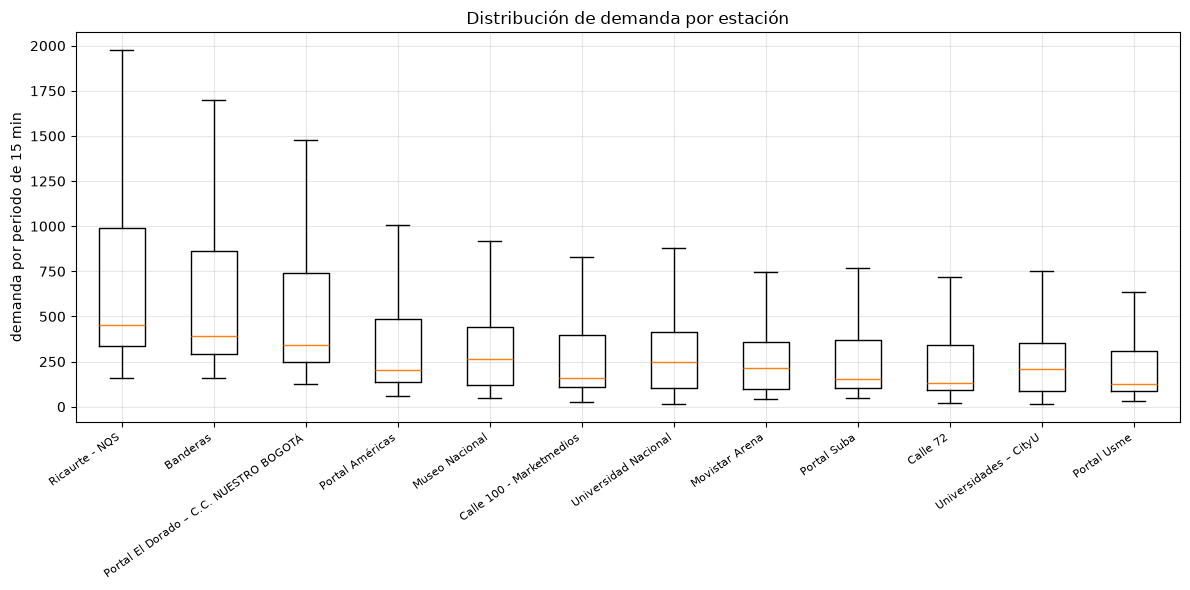

In [7]:
order = stats.index.tolist()
figure, axes = plt.subplots(figsize=(12, 6))
axes.boxplot(
    [observations.loc[observations["station_id"] == s, "demand"] for s in order],
    tick_labels=stats["station_name"].tolist(),
    showfliers=False,
)
axes.set_title("Distribución de demanda por estación")
axes.set_ylabel("demanda por periodo de 15 min")
axes.tick_params(axis="x", labelrotation=35, labelsize=8)
for label in axes.get_xticklabels():
    label.set_ha("right")
figure.tight_layout()
plt.show()

**Resultado:** la demanda media varía más de 3× entre estaciones (Ricaurte-NQS ~684 frente a
Portal Usme ~218). En todas la mediana queda muy por debajo de la media, es decir, distribuciones
sesgadas a la derecha: muchos periodos de demanda baja y picos pronunciados en hora punta.

El `cv` entre 0.66 y 0.95 confirma que ninguna estación es "plana" — todas dependen fuertemente
de la hora del día, que es justo lo que revisa la sección 4.

## 3. Distribución geográfica

`stations.csv` trae latitud y longitud, así que se puede ver cómo se reparte la demanda sobre la
ciudad. La pregunta interesante no es solo *dónde* está cada estación, sino si su **rol dentro del
viaje** cambia con la ubicación.

Para responderla se compara el pico de la mañana (6–8h) con el de la tarde (16–18h):

- `ratio > 1` → estación de **origen**: la gente sale de ahí por la mañana (zona residencial).
- `ratio < 1` → estación de **destino**: la gente llega por la mañana y regresa por la tarde
  (empleo, estudio, ocio).

Se agrega también la distancia a un punto céntrico de referencia para contrastar centro y periferia.

In [8]:
peaks = observations.groupby(["station_id", "hour"])["demand"].mean().unstack()

geo = stations.set_index("station_id").copy()
geo["media"] = observations.groupby("station_id")["demand"].mean()
geo["pico_am"] = peaks[[6, 7, 8]].mean(axis=1)
geo["pico_pm"] = peaks[[16, 17, 18]].mean(axis=1)
geo["ratio_am_pm"] = geo["pico_am"] / geo["pico_pm"]
geo["dist_centro_km"] = np.hypot(
    (geo["latitude"] - CENTER_LAT) * 111,
    (geo["longitude"] - CENTER_LON) * 111 * np.cos(np.radians(CENTER_LAT)),
)

columns = ["station_name", "corridor", "dist_centro_km", "media", "pico_am", "pico_pm", "ratio_am_pm"]
geo[columns].sort_values("ratio_am_pm").round(2)

,station_name,corridor,dist_centro_km,media,pico_am,pico_pm,ratio_am_pm
station_id,,,,,,,
07105,Movistar Arena,NQS,4.49,272.59,94.75,468.19,0.20
10009,Museo Nacional,Carrera 7-10,1.51,337.92,108.56,478.25,0.23
02300,Calle 100 - Marketmedios,Autonorte,8.66,293.97,506.53,773.09,0.66
09122,Calle 72,Caracas,5.81,249.80,479.08,648.59,0.74
07111,Ricaurte - NQS,NQS,1.36,683.72,1324.86,1373.17,0.96
05100,Banderas,Américas,7.48,591.06,1173.08,1164.19,1.01
06000,Portal El Dorado – C.C. NUESTRO BOGOTÁ,Calle 26,9.11,510.94,1007.41,975.94,1.03
09000,Portal Usme,Caracas,9.61,217.87,464.06,367.69,1.26
06111,Universidades – CityU,Calle 26,1.69,238.89,298.84,228.06,1.31


### Mapa de demanda

Cada punto es una estación en sus coordenadas reales, con el área proporcional a su demanda media
y el color indicando el corredor.

El `set_aspect` corrige la proporción: un grado de longitud equivale a ~111·cos(latitud) km
mientras que uno de latitud son ~111 km. Sin esa corrección el mapa sale horizontalmente estirado
y las distancias engañan.

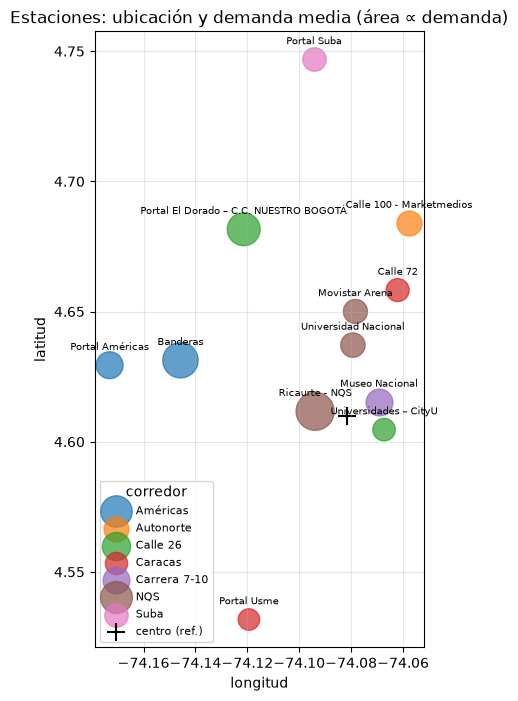

In [9]:
figure, axes = plt.subplots(figsize=(9, 8))

for corridor, group in geo.groupby("corridor"):
    axes.scatter(group["longitude"], group["latitude"], s=group["media"] * 1.1, alpha=0.7, label=corridor)

for _, row in geo.iterrows():
    axes.annotate(
        row["station_name"],
        (row["longitude"], row["latitude"]),
        fontsize=7.5,
        xytext=(0, 11),
        textcoords="offset points",
        ha="center",
    )

axes.scatter(CENTER_LON, CENTER_LAT, marker="+", s=180, color="black", label="centro (ref.)")
axes.set_aspect(1 / np.cos(np.radians(CENTER_LAT)))
axes.set_xlabel("longitud")
axes.set_ylabel("latitud")
axes.set_title("Estaciones: ubicación y demanda media (área ∝ demanda)")
axes.legend(fontsize=8, title="corredor", loc="lower left")
plt.show()

### Mapa de rol origen/destino

El mismo mapa, ahora coloreado por el cociente AM/PM con una escala divergente centrada en 1:
rojo = estación de origen (sale gente en la mañana), azul = estación de destino.

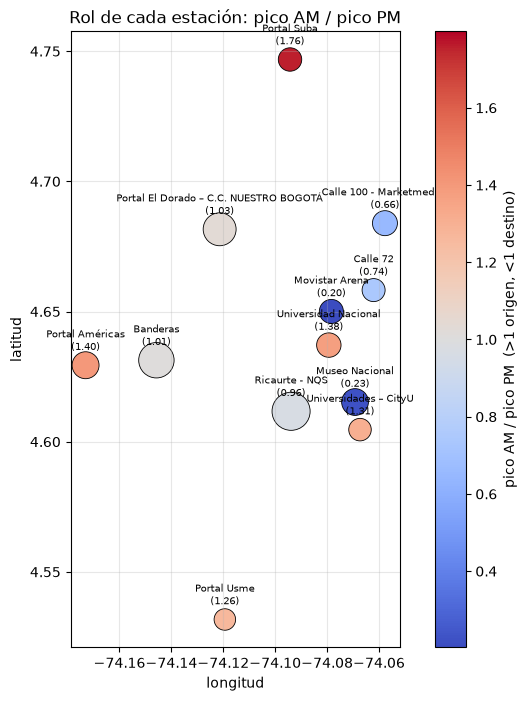

In [10]:
figure, axes = plt.subplots(figsize=(9, 8))

limit = (geo["ratio_am_pm"] - 1).abs().max()
points = axes.scatter(
    geo["longitude"],
    geo["latitude"],
    c=geo["ratio_am_pm"],
    cmap="coolwarm",
    vmin=1 - limit,
    vmax=1 + limit,
    s=geo["media"] * 1.1,
    edgecolor="black",
    linewidth=0.6,
)

for _, row in geo.iterrows():
    axes.annotate(
        f"{row['station_name']}\n({row['ratio_am_pm']:.2f})",
        (row["longitude"], row["latitude"]),
        fontsize=7.5,
        xytext=(0, 11),
        textcoords="offset points",
        ha="center",
    )

axes.set_aspect(1 / np.cos(np.radians(CENTER_LAT)))
axes.set_xlabel("longitud")
axes.set_ylabel("latitud")
axes.set_title("Rol de cada estación: pico AM / pico PM")
figure.colorbar(points, ax=axes, label="pico AM / pico PM  (>1 origen, <1 destino)")
plt.show()

### Centro frente a periferia

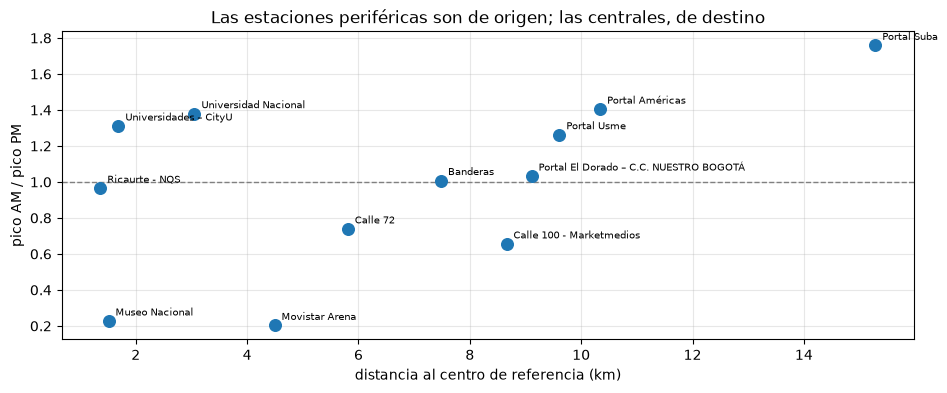

corr(distancia, ratio AM/PM) = 0.507
corr(distancia, demanda media) = -0.189

Promedio por tipo de estación:
              dist_centro_km   media  ratio_am_pm
station_name                                     
no portal               4.26  368.62         0.81
portal                 11.09  332.32         1.36


In [11]:
figure, axes = plt.subplots()
axes.scatter(geo["dist_centro_km"], geo["ratio_am_pm"], s=70, zorder=3)
axes.axhline(1, linestyle="--", color="gray", linewidth=1)

for _, row in geo.iterrows():
    axes.annotate(
        row["station_name"],
        (row["dist_centro_km"], row["ratio_am_pm"]),
        fontsize=7.5,
        xytext=(5, 4),
        textcoords="offset points",
    )

axes.set_xlabel("distancia al centro de referencia (km)")
axes.set_ylabel("pico AM / pico PM")
axes.set_title("Las estaciones periféricas son de origen; las centrales, de destino")
plt.show()

print(f"corr(distancia, ratio AM/PM) = {geo['dist_centro_km'].corr(geo['ratio_am_pm']):.3f}")
print(f"corr(distancia, demanda media) = {geo['dist_centro_km'].corr(geo['media']):.3f}")

es_portal = geo["station_name"].str.contains("Portal")
print("\nPromedio por tipo de estación:")
print(geo.groupby(es_portal)[["dist_centro_km", "media", "ratio_am_pm"]].mean().round(2).rename(index={True: "portal", False: "no portal"}).to_string())

**Resultado:** la geografía explica el *rol* de la estación, no su tamaño.

- **El cociente AM/PM se ordena espacialmente** (corr con la distancia = 0.507). Los cuatro portales,
  a 9–15 km del centro, son claramente de origen (ratio medio 1.36, con Portal Suba en 1.76);
  las estaciones centrales son de destino (Museo Nacional 0.23, Movistar Arena 0.20).
- **La distancia no predice el volumen** (corr = -0.19). Las estaciones más cargadas son Ricaurte-NQS
  y Banderas, que son nodos de transferencia entre corredores, no extremos de la red.
- **Las excepciones tienen sentido.** Universidad Nacional (1.38) y Universidades–CityU (1.31) son
  centrales pero se comportan como origen — son campus con llegada matutina concentrada.
  Movistar Arena es el caso opuesto extremo: un recinto de eventos, con casi toda su demanda en la tarde.

**Implicación para el modelo:** el `station_id` por sí solo obliga al modelo a aprender doce perfiles
independientes. Añadir features que capturen este rol —el cociente AM/PM histórico, si es portal,
la distancia al centro, el corredor— permite compartir estructura entre estaciones parecidas y ayuda
sobre todo en las de menor volumen, que pesan igual en la métrica promediada por estación.

## 4. Patrones temporales

Aquí se busca la estacionalidad que el modelo debe capturar. Se revisan tres cortes:
perfil por hora, perfil por día de semana, y la interacción de ambos.

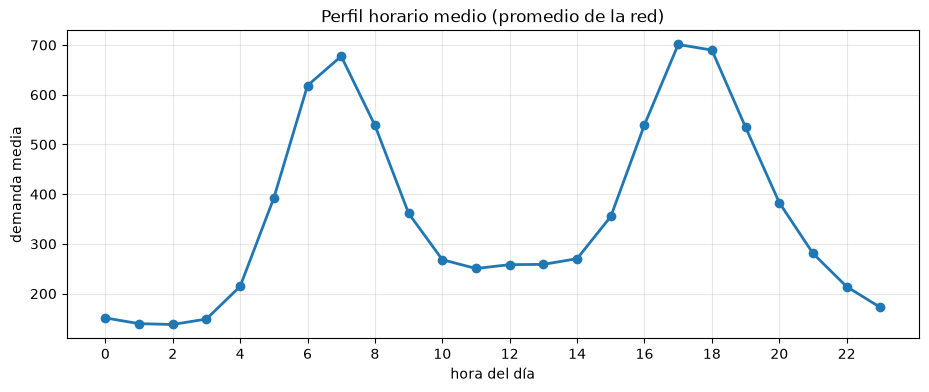

In [12]:
hourly = observations.groupby("hour")["demand"].mean()

figure, axes = plt.subplots()
axes.plot(hourly.index, hourly.values, marker="o", linewidth=2)
axes.set_title("Perfil horario medio (promedio de la red)")
axes.set_xlabel("hora del día")
axes.set_ylabel("demanda media")
axes.set_xticks(range(0, 24, 2))
plt.show()

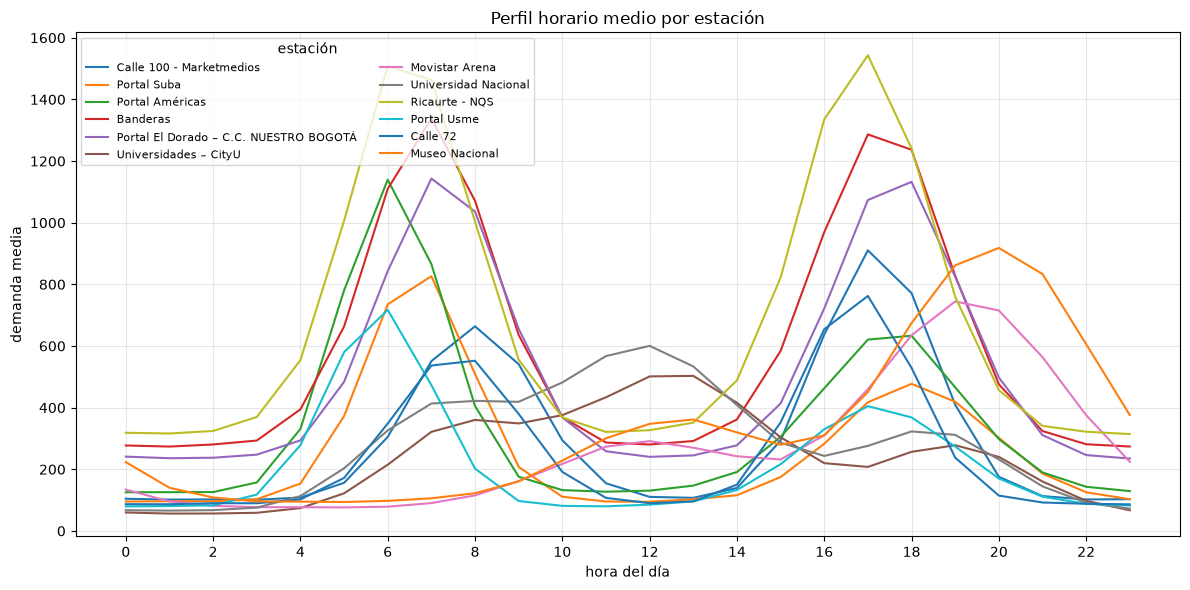

In [13]:
names = stations.set_index("station_id")["station_name"]
by_station = observations.pivot_table(index="hour", columns="station_id", values="demand", aggfunc="mean")
by_station = by_station.rename(columns=names)

figure, axes = plt.subplots(figsize=(12, 6))
by_station.plot(ax=axes, linewidth=1.5)
axes.set_title("Perfil horario medio por estación")
axes.set_xlabel("hora del día")
axes.set_ylabel("demanda media")
axes.set_xticks(range(0, 24, 2))
axes.legend(fontsize=8, ncol=2, title="estación", loc="upper left")
figure.tight_layout()
plt.show()

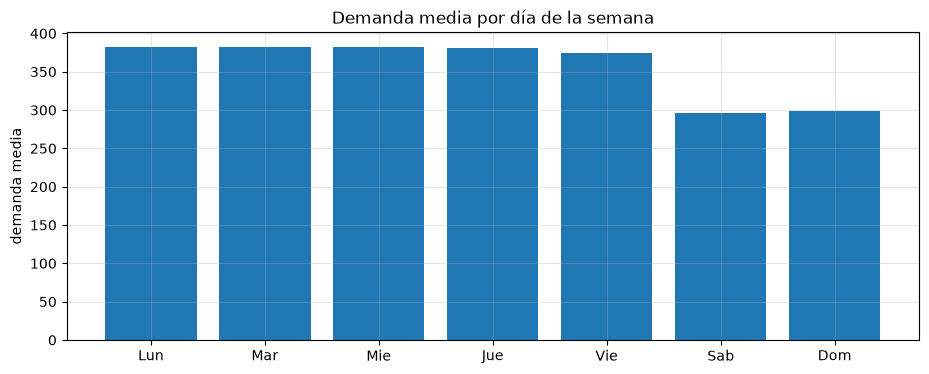

Entre semana   : 380.5
Fin de semana  : 297.6
Diferencia     : -21.8%


In [14]:
weekday = observations.groupby("weekday")["demand"].mean()

figure, axes = plt.subplots()
axes.bar([WEEKDAYS[i] for i in weekday.index], weekday.values)
axes.set_title("Demanda media por día de la semana")
axes.set_ylabel("demanda media")
plt.show()

weekend = observations.groupby(observations["weekday"] >= 5)["demand"].mean()
print(f"Entre semana   : {weekend[False]:.1f}")
print(f"Fin de semana  : {weekend[True]:.1f}")
print(f"Diferencia     : {100 * (weekend[True] / weekend[False] - 1):.1f}%")

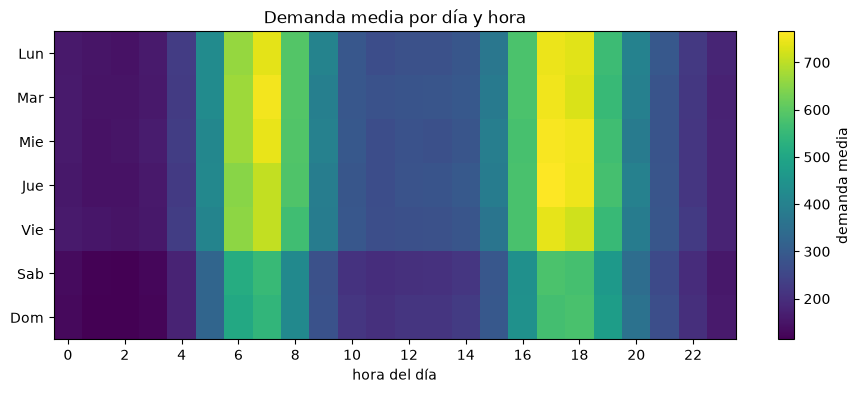

In [15]:
grid = observations.pivot_table(index="weekday", columns="hour", values="demand", aggfunc="mean")

figure, axes = plt.subplots(figsize=(11, 4))
image = axes.imshow(grid.values, aspect="auto", cmap="viridis")
axes.set_yticks(range(len(grid.index)), [WEEKDAYS[i] for i in grid.index])
axes.set_xticks(range(0, 24, 2), range(0, 24, 2))
axes.set_title("Demanda media por día y hora")
axes.set_xlabel("hora del día")
axes.grid(False)
figure.colorbar(image, ax=axes, label="demanda media")
plt.show()

**Resultado:** patrón de doble pico típico de transporte urbano — máximos hacia las 7am (~677)
y las 5pm (~701), con valle nocturno cerca de 140. Todas las estaciones comparten esa forma,
aunque con amplitudes distintas.

El fin de semana la demanda cae ~22% y el mapa día×hora muestra que el pico matutino casi
desaparece el sábado y domingo, mientras el vespertino se mantiene aunque atenuado. Es decir:
**hora del día y tipo de día interactúan**, no son efectos independientes. Un modelo con features
de hora y día por separado capturará menos que uno que incluya su interacción (o que use lags
semanales, como sugiere la sección 6).

## 5. Deriva temporal

El README advierte que algunos patrones cambian durante la competencia. Esta sección compara
la media de los últimos 7 días contra el resto del histórico, por estación.

Es exactamente el tipo de chequeo que después vive en `monitor.py`: si la deriva supera un umbral,
el pipeline debería decidir reentrenar.

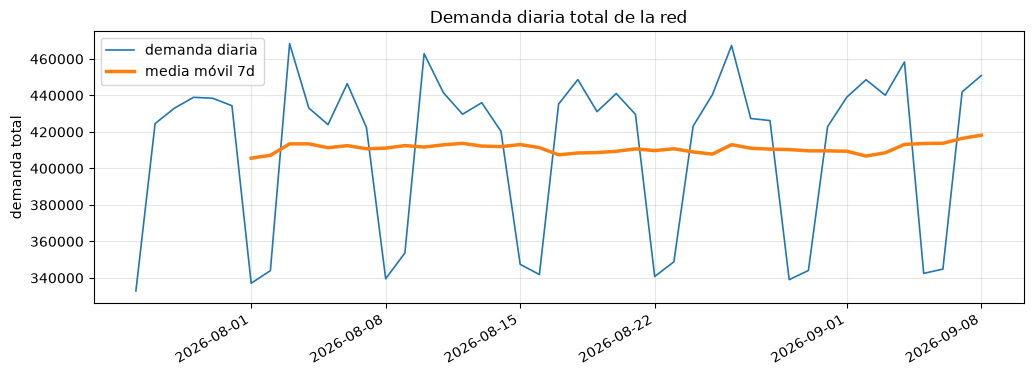

In [16]:
daily = observations.groupby("date")["demand"].sum()

figure, axes = plt.subplots(figsize=(12, 4))
axes.plot(daily.index, daily.values, linewidth=1.2, label="demanda diaria")
axes.plot(daily.index, daily.rolling(7).mean().values, linewidth=2.5, label="media móvil 7d")
axes.set_title("Demanda diaria total de la red")
axes.set_ylabel("demanda total")
axes.legend()
figure.autofmt_xdate()
plt.show()

In [17]:
cutoff = observations["observed_at"].max() - timedelta(days=7)
early = observations.loc[observations["observed_at"] <= cutoff].groupby("station_id")["demand"].mean()
late = observations.loc[observations["observed_at"] > cutoff].groupby("station_id")["demand"].mean()

drift = pd.DataFrame({"historico": early, "ultimos_7d": late})
drift["cambio_pct"] = 100 * (drift["ultimos_7d"] / drift["historico"] - 1)
drift.join(stations.set_index("station_id")["station_name"]).sort_values("cambio_pct").round(2)

,historico,ultimos_7d,cambio_pct,station_name
station_id,,,,
06000,510.28,514.54,0.83,Portal El Dorado – C.C. NUESTRO BOGOTÁ
05000,341.54,344.86,0.97,Portal Américas
10009,337.15,342.11,1.47,Museo Nacional
07105,271.96,275.99,1.48,Movistar Arena
07111,682.07,692.67,1.56,Ricaurte - NQS
05100,589.20,601.18,2.03,Banderas
09122,248.95,254.41,2.19,Calle 72
09000,216.84,223.43,3.03,Portal Usme
03000,257.20,265.10,3.07,Portal Suba


**Resultado:** la serie diaria es muy estable en nivel — la media móvil de 7 días apenas se mueve;
la oscilación visible es el ciclo semanal (caídas de fin de semana), no una tendencia.

Aun así, **las 12 estaciones suben** entre 0.8% y 4.6% en los últimos 7 días. Que el cambio sea
positivo en todas y no aleatorio sugiere una deriva leve pero sistemática. Todavía no es grave,
pero confirma que vale la pena monitorearla en vez de entrenar una sola vez.

## 6. Autocorrelación

¿Qué tan bien predice el pasado al presente? Se mide la correlación de la demanda consigo misma
desplazada: 15 minutos, 1 hora, 1 día (96 periodos) y 1 semana (672 periodos).

El baseline de `examples/02_naive_baseline.py` usa el lag de 1 día. Esta tabla permite verificar
si esa es la mejor elección.

In [18]:
rows = {}
for station_id, group in observations.groupby("station_id"):
    demand = group["demand"].reset_index(drop=True)
    rows[station_id] = {
        "lag_15min": demand.autocorr(1),
        "lag_1h": demand.autocorr(4),
        "lag_1dia": demand.autocorr(DAY_LAG),
        "lag_1semana": demand.autocorr(WEEK_LAG),
    }

lags = pd.DataFrame(rows).T
lags.insert(0, "station_name", stations.set_index("station_id")["station_name"])
display(lags.round(3))
print("\nPromedio de la red:")
print(lags.drop(columns="station_name").mean().round(3).to_string())

,station_name,lag_15min,lag_1h,lag_1dia,lag_1semana
02300,Calle 100 - Marketmedios,0.941,0.761,0.845,0.948
03000,Portal Suba,0.947,0.736,0.944,0.957
05000,Portal Américas,0.943,0.733,0.943,0.956
05100,Banderas,0.934,0.757,0.923,0.939
06000,Portal El Dorado – C.C. NUESTRO BOGOTÁ,0.920,0.745,0.913,0.931
06111,Universidades – CityU,0.942,0.883,0.788,0.941
07105,Movistar Arena,0.943,0.867,0.903,0.926
07107,Universidad Nacional,0.947,0.887,0.792,0.940
07111,Ricaurte - NQS,0.929,0.748,0.923,0.939
09000,Portal Usme,0.939,0.732,0.940,0.951



Promedio de la red:
lag_15min      0.940
lag_1h         0.790
lag_1dia       0.890
lag_1semana    0.943


**Resultado — el hallazgo más accionable del EDA:** el lag de **1 semana (0.943) supera al de 1 día
(0.890)**. Tiene sentido dado el patrón de la sección 4: un martes se parece más a otro martes que
a un lunes, y el fin de semana rompe por completo la comparación día a día.

La caída del lag de 1 hora (0.790) frente al de 15 minutos (0.940) refleja la pendiente de las horas
punta: una hora atrás, dentro de un pico, es un mal predictor.

Además, tres estaciones (`06111`, `07107`, `10009`) tienen un lag diario notablemente más débil
(~0.79–0.90) pero lag semanal normal, así que son las que más se benefician del cambio.

**Implicación:** cambiar `shift(96)` por `shift(672)` en el baseline debería mejorarlo, y el modelo
final debería incluir lags semanales entre sus features.

## 7. Contexto: clima y eventos

Hay una trampa importante en estas variables. El dataset trae el valor **real** (`rain_mm`,
`temperature_c`) y el **pronóstico** (`rain_forecast`, `temperature_forecast`). Al momento de
predecir el futuro solo se dispone del pronóstico, así que usar el valor real como feature sería
fuga de información (*leakage*) y produciría métricas infladas que no se sostienen en producción.

Por eso se revisan dos cosas: si el contexto correlaciona con la demanda, y qué tan fiel es el
pronóstico al valor real.

In [19]:
context.drop(columns="observed_at").describe().round(3)

,rain_mm,rain_forecast,temperature_c,temperature_forecast,event_intensity
count,4320.000,4320.000,4320.000,4320.000,4320.000
mean,0.260,0.381,14.507,14.506,0.032
std,0.516,0.569,4.180,4.258,0.147
min,0.000,0.000,6.753,5.449,0.000
25%,0.005,0.000,10.483,10.627,0.000
50%,0.062,0.178,14.519,14.453,0.000
75%,0.282,0.564,18.539,18.426,0.000
max,7.722,7.461,22.321,23.568,1.000


In [20]:
total = observations.groupby("observed_at")["demand"].sum().rename("demand_total")
merged = context.merge(total, on="observed_at", how="inner")

drivers = ["rain_mm", "rain_forecast", "temperature_c", "temperature_forecast", "event_intensity"]
merged[drivers + ["demand_total"]].corr()["demand_total"].drop("demand_total").round(3).to_frame("corr_con_demanda")

,corr_con_demanda
rain_mm,-0.017
rain_forecast,-0.013
temperature_c,0.343
temperature_forecast,0.339
event_intensity,0.145


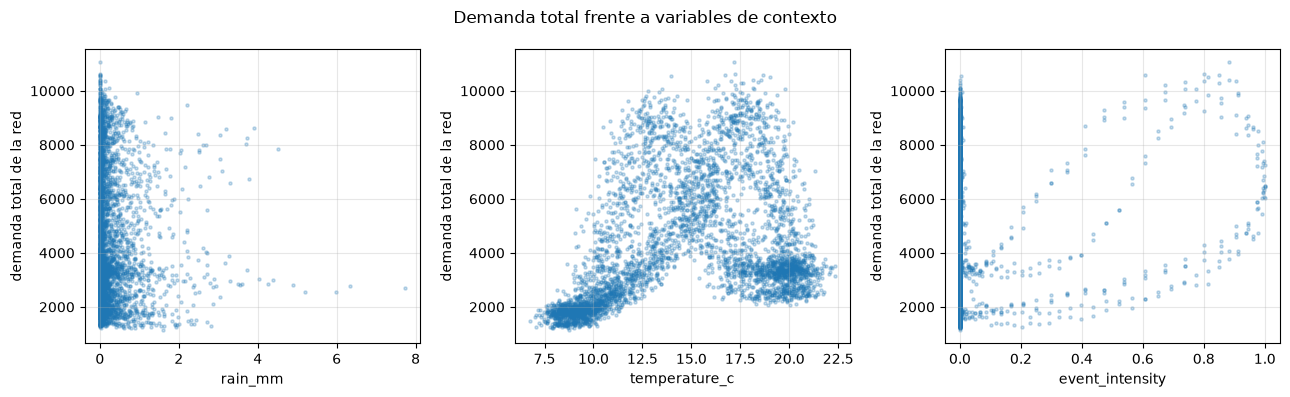

In [21]:
figure, axes = plt.subplots(1, 3, figsize=(13, 4))
for axis, column in zip(axes, ["rain_mm", "temperature_c", "event_intensity"]):
    axis.scatter(merged[column], merged["demand_total"], s=5, alpha=0.25)
    axis.set_xlabel(column)
    axis.set_ylabel("demanda total de la red")
figure.suptitle("Demanda total frente a variables de contexto")
figure.tight_layout()
plt.show()

In [22]:
print("Fidelidad del pronóstico (lo único disponible al predecir):")
print(f"  corr(rain_forecast, rain_mm)              = {merged['rain_forecast'].corr(merged['rain_mm']):.3f}")
print(f"  corr(temperature_forecast, temperature_c) = {merged['temperature_forecast'].corr(merged['temperature_c']):.3f}")

intensity = context["event_intensity"]
print("\nCuidado con event_intensity: umbral importa.")
for threshold in (0, 0.01, 0.1, 0.5):
    print(f"  intensidad > {threshold:<4} : {(intensity > threshold).mean():6.1%} de los periodos")
print(f"  exactamente 0    : {(intensity == 0).mean():6.1%}")
print(f"  menor valor no nulo: {intensity[intensity > 0].min():.3g}")

Fidelidad del pronóstico (lo único disponible al predecir):
  corr(rain_forecast, rain_mm)              = 0.823
  corr(temperature_forecast, temperature_c) = 0.982

Cuidado con event_intensity: umbral importa.
  intensidad > 0    :  89.5% de los periodos
  intensidad > 0.01 :   7.8% de los periodos
  intensidad > 0.1  :   5.5% de los periodos
  intensidad > 0.5  :   3.0% de los periodos
  exactamente 0    :  10.5%
  menor valor no nulo: 9.88e-324


**Resultado:** la lluvia prácticamente no explica la demanda (corr ≈ -0.02). La temperatura sí
muestra relación (0.343), pero conviene leerla con cuidado: la temperatura sigue el ciclo diario,
así que buena parte de esa correlación es la hora del día disfrazada, no un efecto causal del clima.
Los eventos aportan poco en promedio (0.145), pero la columna esconde una trampa: `event_intensity > 0`
es cierto en el **89.5%** de los periodos, no porque haya eventos constantes sino porque el generador
deja valores denormales minúsculos (el menor no nulo es del orden de 1e-323). Con umbrales razonables
los eventos son raros: solo **5.5%** de los periodos superan 0.1 y **3.0%** superan 0.5. Construir una
bandera booleana con `> 0` marcaría casi todo el dataset como "hay evento" y sería inútil; hay que
umbralizar.

La buena noticia es que los pronósticos son fieles (temperatura 0.982, lluvia 0.823), así que se
pueden usar como features sin perder casi información frente al valor real — y **sin leakage**.

## 8. Matriz de correlación

Las secciones anteriores miraron cada señal por separado. Aquí se juntan todas en una sola tabla de
features —lags, calendario y contexto pronosticado— para ver cómo se relacionan **entre sí**, no solo
con la demanda.

Eso importa por dos razones: features muy correlacionadas entre sí aportan información redundante,
y la correlación con el objetivo ayuda a priorizar cuáles construir primero.

Solo se usan las columnas `_forecast` del contexto, por lo explicado en la sección 7.

In [23]:
features = observations[["station_id", "observed_at", "demand", "hour", "weekday"]].copy()
grouped = features.groupby("station_id")["demand"]

features["lag_15min"] = grouped.shift(1)
features["lag_1dia"] = grouped.shift(DAY_LAG)
features["lag_1semana"] = grouped.shift(WEEK_LAG)
features["media_movil_1dia"] = grouped.transform(lambda s: s.shift(1).rolling(DAY_LAG).mean())
features["hora_sin"] = np.sin(2 * np.pi * features["hour"] / 24)
features["hora_cos"] = np.cos(2 * np.pi * features["hour"] / 24)
features["fin_semana"] = (features["weekday"] >= 5).astype(int)

features = features.merge(
    context[["observed_at", "rain_forecast", "temperature_forecast", "event_intensity"]],
    on="observed_at",
    how="left",
)

COLUMNS = [
    "demand", "lag_15min", "lag_1dia", "lag_1semana", "media_movil_1dia",
    "hora_sin", "hora_cos", "fin_semana",
    "rain_forecast", "temperature_forecast", "event_intensity",
]
features = features.dropna(subset=COLUMNS)
correlation = features[COLUMNS].corr()
correlation.round(2)

,demand,lag_15min,lag_1dia,lag_1semana,media_movil_1dia,hora_sin,hora_cos,fin_semana,rain_forecast,temperature_forecast,event_intensity
demand,1.00,0.95,0.92,0.95,0.47,-0.09,-0.19,-0.12,-0.01,0.20,0.10
lag_15min,0.95,1.00,0.92,0.94,0.47,-0.11,-0.18,-0.12,-0.00,0.20,0.10
lag_1dia,0.92,0.92,1.00,0.92,0.48,-0.10,-0.19,-0.05,0.01,0.20,0.05
lag_1semana,0.95,0.94,0.92,1.00,0.47,-0.09,-0.19,-0.12,0.01,0.20,0.06
media_movil_1dia,0.47,0.47,0.48,0.47,1.00,-0.00,-0.00,-0.17,0.00,0.00,0.05
hora_sin,-0.09,-0.11,-0.10,-0.09,-0.00,1.00,-0.00,-0.00,0.01,-0.40,-0.23
hora_cos,-0.19,-0.18,-0.19,-0.19,-0.00,-0.00,1.00,-0.00,-0.04,-0.88,0.09
fin_semana,-0.12,-0.12,-0.05,-0.12,-0.17,-0.00,-0.00,1.00,0.01,0.00,-0.14
rain_forecast,-0.01,-0.00,0.01,0.01,0.00,0.01,-0.04,0.01,1.00,0.04,-0.02
temperature_forecast,0.20,0.20,0.20,0.20,0.00,-0.40,-0.88,0.00,0.04,1.00,0.02


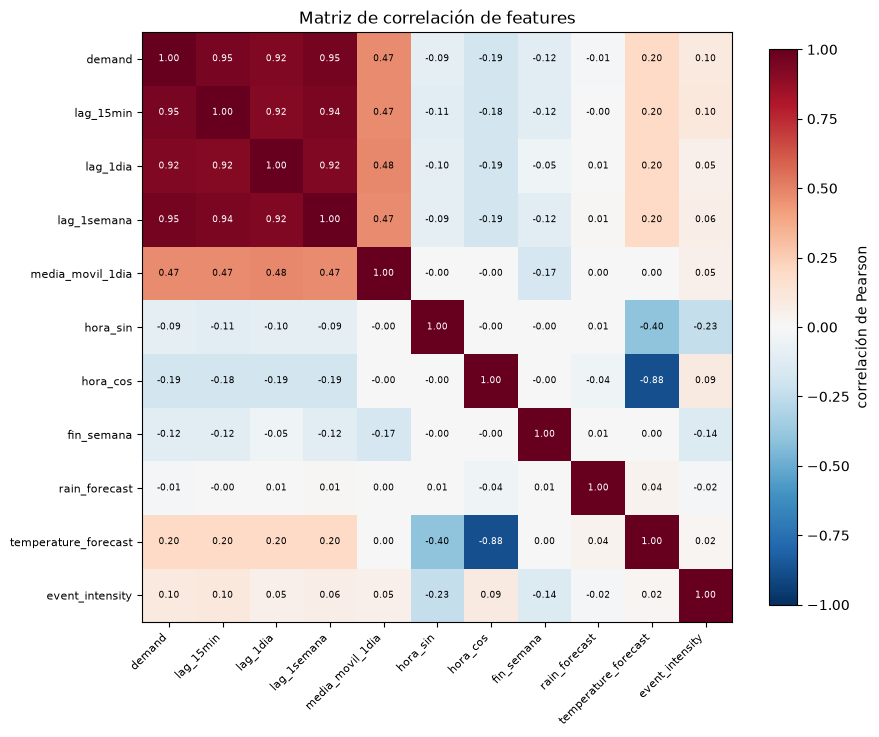

In [24]:
figure, axes = plt.subplots(figsize=(9, 8))
image = axes.imshow(correlation.values, cmap="RdBu_r", vmin=-1, vmax=1)

axes.set_xticks(range(len(COLUMNS)), COLUMNS, rotation=45, ha="right", fontsize=8)
axes.set_yticks(range(len(COLUMNS)), COLUMNS, fontsize=8)

for i in range(len(COLUMNS)):
    for j in range(len(COLUMNS)):
        value = correlation.values[i, j]
        axes.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=6.5,
                  color="white" if abs(value) > 0.6 else "black")

axes.set_title("Matriz de correlación de features")
axes.grid(False)
figure.colorbar(image, ax=axes, shrink=0.8, label="correlación de Pearson")
figure.tight_layout()
plt.show()

### Agrupada frente a intra-estación

La matriz anterior mezcla las 12 estaciones, así que parte de la correlación viene simplemente de que
unas estaciones son más grandes que otras, no de la dinámica temporal. Calcular la correlación dentro
de cada estación y luego promediar separa un efecto del otro.

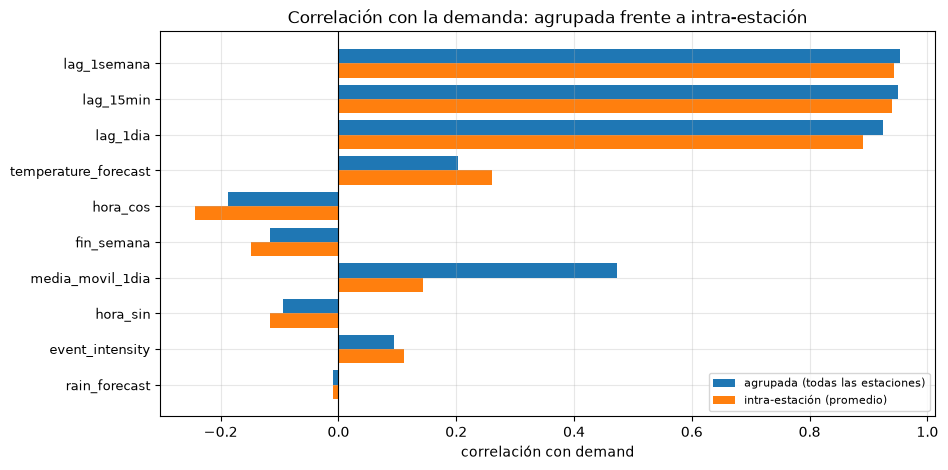

,agrupada,intra_estacion,diferencia
lag_1semana,0.953,0.943,0.011
lag_15min,0.950,0.940,0.010
lag_1dia,0.925,0.891,0.033
temperature_forecast,0.203,0.261,-0.058
hora_cos,-0.187,-0.243,0.056
fin_semana,-0.117,-0.148,0.031
media_movil_1dia,0.473,0.144,0.329
hora_sin,-0.094,-0.117,0.022
event_intensity,0.095,0.111,-0.016
rain_forecast,-0.010,-0.010,0.000


In [25]:
pooled = correlation["demand"].drop("demand")
within = (
    features.groupby("station_id")[COLUMNS].corr()["demand"]
    .unstack()
    .drop(columns="demand")
    .mean()
)

comparison = pd.DataFrame({"agrupada": pooled, "intra_estacion": within})
comparison["diferencia"] = comparison["agrupada"] - comparison["intra_estacion"]
comparison = comparison.reindex(comparison["intra_estacion"].abs().sort_values(ascending=False).index)

figure, axes = plt.subplots(figsize=(10, 5))
positions = np.arange(len(comparison))
axes.barh(positions - 0.2, comparison["agrupada"], height=0.4, label="agrupada (todas las estaciones)")
axes.barh(positions + 0.2, comparison["intra_estacion"], height=0.4, label="intra-estación (promedio)")
axes.set_yticks(positions, comparison.index, fontsize=9)
axes.axvline(0, color="black", linewidth=0.8)
axes.invert_yaxis()
axes.set_xlabel("correlación con demand")
axes.set_title("Correlación con la demanda: agrupada frente a intra-estación")
axes.legend(fontsize=8)
plt.show()

comparison.round(3)

**Resultado — cuatro lecturas, y tres de ellas son advertencias:**

**1. Los lags dominan, y el semanal gana otra vez.** `lag_1semana` (0.953) supera a `lag_15min` (0.950)
y a `lag_1dia` (0.925), consistente con la sección 6. Son, por mucho, las features más informativas.

**2. La temperatura es el ciclo diario disfrazado.** `temperature_forecast` correlaciona **-0.878 con
`hora_cos`** — casi colineales. Esto confirma la sospecha de la sección 7: su correlación con la demanda
(0.20) no es un efecto del clima, es la hora del día entrando por la puerta de atrás. Con features de
hora en el modelo, la temperatura aporta poco y además introduce redundancia.

**3. Correlación no es importancia.** `hora_sin` y `hora_cos` muestran correlaciones bajísimas
(-0.09 y -0.19) pese a que la sección 4 mostró que **la hora es el patrón más fuerte del dataset**.
La razón es que Pearson mide relaciones *lineales* y el perfil horario tiene **dos picos**: sube por la
mañana, baja al mediodía, vuelve a subir en la tarde. Una relación así se cancela en promedio.
Descartar la hora por su correlación baja sería un error grave — conviene codificarla como categórica
o mediante interacciones, no como una sola variable continua.

**4. Agrupar infla las correlaciones.** `media_movil_1dia` pasa de 0.473 agrupada a **0.144 intra-estación**:
la mayor parte de esa señal era solo "las estaciones grandes tienen medias grandes", no capacidad
predictiva real dentro de una estación. Los lags, en cambio, apenas cambian entre ambas vistas
(0.953 → 0.943), lo que confirma que su señal sí es temporal y genuina.

## 9. Conclusiones para el pipeline

| # | Hallazgo | Qué hacer |
|---|---|---|
| 1 | Datos completos: sin huecos, duplicados ni nulos | No se requiere imputación; cualquier `NaN` posterior es un bug propio |
| 2 | Demanda varía 3× entre estaciones; WAPE se promedia por estación | Evaluar por estación, no solo en agregado |
| 3 | La geografía define el rol: periferia = origen, centro = destino | Añadir features de rol (portal, cociente AM/PM, corredor) para compartir estructura |
| 4 | Doble pico (7am / 5pm) e interacción fuerte hora × tipo de día | Incluir features de hora, día y su interacción |
| 5 | Deriva leve pero sistemática (+0.8% a +4.6% en 7 días) | Monitorear con un umbral explícito que dispare reentrenamiento |
| 6 | Lag semanal (0.943) > lag diario (0.890) | Usar `shift(672)`; mejora esperada sobre el baseline actual |
| 7 | Pronósticos fieles al valor real | Usar las columnas `_forecast` como features, nunca las reales |
| 8 | `temperature_forecast` es casi colineal con `hora_cos` (-0.878) | No esperar aporte del clima si ya hay features de hora |
| 9 | La hora tiene correlación lineal baja pero es el patrón más fuerte | No seleccionar features solo por correlación; codificar la hora como categórica |

**Validación:** siempre partición temporal (por ejemplo 38 días de entrenamiento y 7 de validación).
Una partición aleatoria mezclaría futuro y pasado y daría métricas engañosas.